# Phase 2 — Model Development & Phase 1 vs Phase 2 Comparison

**Scope:** sections 2–4 (monitoring, profiling, experiment tracking) on the `model_v2` branch.

This notebook simulates the way a developer would explore Phase 2 model development on top of the reproducible pipeline:

1. Load the same config the DVC pipeline uses (single source of truth).
2. Inspect the **deterministic 60 / 20 / 20 phase partitions** (Phase 1 reference / Phase 2 increment / Phase 3 holdout).
3. Confirm that the Phase 2 training run produced the expected per-model metrics and a saved `best_model.joblib`.
4. Compare **Phase 1 baseline metrics** (committed under `reports/metrics/phase1_baseline/`) with the new **Phase 2 metrics**.
5. Re-score the Phase 2 **increment** with both the Phase 1 baseline and Phase 2 winner so we can quantify the lift from the extra 20 %.
6. Surface the false-negative deep-dive (recall matters most for phishing).

All cells are read-only against the artifacts produced by `dvc repro`; nothing here rewrites pipeline outputs.

## 1. Setup

Load the project config and the artifact directories. If any path is missing, run `make repro` from the repo root first.

In [1]:
import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import pandas as pd

from mlops_crew.config import CONFIG_PATH, PROJECT_ROOT, load_project_config, resolve_project_path
from mlops_crew.data import LABEL_COLUMN, TEXT_COLUMN
from mlops_crew.evaluation.metrics import binary_classification_report

config = load_project_config(CONFIG_PATH)
phase2_metrics_dir = resolve_project_path(config["reports"]["metrics_dir"])
phase1_metrics_dir = phase2_metrics_dir / "phase1_baseline"
models_dir = resolve_project_path(config["modeling"]["output_dir"])
interim_dir = resolve_project_path(config["data"]["interim_dir"])
processed_dir = resolve_project_path(config["data"]["processed_dir"])
divergence_dir = resolve_project_path(config["reports"]["divergence_dir"])

for label, p in {
    "phase2_metrics_dir": phase2_metrics_dir,
    "phase1_metrics_dir": phase1_metrics_dir,
    "models_dir": models_dir,
    "interim_dir": interim_dir,
    "processed_dir": processed_dir,
    "divergence_dir": divergence_dir,
}.items():
    print(f"{label}: {p}  ->  exists={p.exists()}")

phase2_metrics_dir: /Users/krishnakalakonda/Downloads/ML Ops/mlops_crew/reports/metrics  ->  exists=True
phase1_metrics_dir: /Users/krishnakalakonda/Downloads/ML Ops/mlops_crew/reports/metrics/phase1_baseline  ->  exists=True
models_dir: /Users/krishnakalakonda/Downloads/ML Ops/mlops_crew/models  ->  exists=True
interim_dir: /Users/krishnakalakonda/Downloads/ML Ops/mlops_crew/data/interim  ->  exists=True
processed_dir: /Users/krishnakalakonda/Downloads/ML Ops/mlops_crew/data/processed  ->  exists=True
divergence_dir: /Users/krishnakalakonda/Downloads/ML Ops/mlops_crew/reports/divergence  ->  exists=True


## 2. Phase partitions

Phase 1 used 60 % of the raw 82,486-row dataset. Phase 2 adds the next 20 %. The final 20 % is locked away for Phase 3. The partitioning lives in `src/mlops_crew/data/sample.py:partition_phase_data` and is deterministic / stratified by label.

In [2]:
phase1_ref = pd.read_csv(interim_dir / config["data"]["phase1_reference_file"])
phase2_inc = pd.read_csv(interim_dir / config["data"]["phase2_increment_file"])
phase2_sample = pd.read_csv(interim_dir / config["data"]["sampled_file"])
phase3_hold = pd.read_csv(interim_dir / config["data"]["phase3_holdout_file"])

summary = pd.DataFrame(
    {
        "rows": [len(phase1_ref), len(phase2_inc), len(phase2_sample), len(phase3_hold)],
        "label_0": [
            (df[LABEL_COLUMN] == 0).sum()
            for df in [phase1_ref, phase2_inc, phase2_sample, phase3_hold]
        ],
        "label_1": [
            (df[LABEL_COLUMN] == 1).sum()
            for df in [phase1_ref, phase2_inc, phase2_sample, phase3_hold]
        ],
    },
    index=[
        "phase1_reference (60%)",
        "phase2_increment (+20%)",
        "phase2_sample (80%)",
        "phase3_holdout (20%)",
    ],
)
summary["positive_rate"] = (summary["label_1"] / summary["rows"]).round(4)
summary

,rows,label_0,label_1,positive_rate
phase1_reference (60%),49492,23757,25735,0.52
phase2_increment (+20%),16497,7919,8578,0.52
phase2_sample (80%),65989,31676,34313,0.52
phase3_holdout (20%),16497,7919,8578,0.52


Sanity-check: the Phase 2 sample and Phase 3 holdout share **no rows** (verified by the raw row index).

In [3]:
from mlops_crew.data import RAW_INDEX_COLUMN

sample_idx = set(phase2_sample[RAW_INDEX_COLUMN])
holdout_idx = set(phase3_hold[RAW_INDEX_COLUMN])
increment_idx = set(phase2_inc[RAW_INDEX_COLUMN])
phase1_idx = set(phase1_ref[RAW_INDEX_COLUMN])

print("phase2_sample ∩ phase3_holdout:", len(sample_idx & holdout_idx))
print("phase1_reference ∩ phase2_increment:", len(phase1_idx & increment_idx))
print(
    "phase1_reference ∪ phase2_increment == phase2_sample:",
    (phase1_idx | increment_idx) == sample_idx,
)

phase2_sample ∩ phase3_holdout: 0
phase1_reference ∩ phase2_increment: 0
phase1_reference ∪ phase2_increment == phase2_sample: True


## 3. Phase 2 metrics (from the latest `dvc repro` run)

In [4]:
phase2_comparison = pd.read_csv(phase2_metrics_dir / "model_comparison.csv")
phase2_comparison.sort_values("val_f2", ascending=False)[
    [
        "model_name",
        "val_f2",
        "test_f2",
        "val_recall",
        "test_recall",
        "val_false_negative_rate",
        "test_false_negative_rate",
    ]
].reset_index(drop=True)

,model_name,val_f2,test_f2,val_recall,test_recall,val_false_negative_rate,test_false_negative_rate
0,linear_svc,0.992381,0.991182,0.992999,0.992222,0.007001,0.007778
1,logistic_regression,0.988185,0.990332,0.988915,0.991834,0.011085,0.008166
2,complement_nb,0.945266,0.951174,0.935045,0.941668,0.064955,0.058332
3,dummy,0.844918,0.844943,1.000000,1.000000,0.000000,0.000000


In [5]:
best = json.loads((phase2_metrics_dir / "best_model_metrics.json").read_text())
print("Phase 2 best model:", best["model_name"])
print("Saved artifact   :", best["model_path"])
print("Saved at         :", (PROJECT_ROOT / best["model_path"]).exists())
pd.DataFrame({"validation": best["validation"], "test": best["test"]})

Phase 2 best model: linear_svc
Saved artifact   : models/linear_svc.joblib
Saved at         : True


,validation,test
accuracy,0.991076,0.989150
average_precision,0.999509,0.999168
f1,0.991456,0.989625
f2,0.992381,0.991182
false_negative,36.000000,40.000000
false_negative_rate,0.007001,0.007778
false_positive,52.000000,67.000000
false_positive_rate,0.011019,0.014198
precision,0.989919,0.987041
recall,0.992999,0.992222


## 4. Phase 1 vs Phase 2 — the gap from adding 20 % more data

Phase 1 trained on 60 % of the raw data with only `dummy` and `logistic_regression`. Phase 2 trains on 80 % and adds `linear_svc` and `complement_nb`.

The comparison below uses the **committed Phase 1 snapshot** under `reports/metrics/phase1_baseline/` so the numbers are reproducible without checking out the `main` branch.

In [6]:
phase1_comparison = pd.read_csv(phase1_metrics_dir / "model_comparison.csv").assign(phase="phase1")
phase2_with_phase = phase2_comparison.assign(phase="phase2")

head_to_head = (
    pd.concat([phase1_comparison, phase2_with_phase], ignore_index=True)[
        [
            "phase",
            "model_name",
            "val_f2",
            "test_f2",
            "val_recall",
            "test_recall",
            "test_false_negative_rate",
        ]
    ]
    .sort_values(["model_name", "phase"])
    .reset_index(drop=True)
)
head_to_head

,phase,model_name,val_f2,test_f2,val_recall,test_recall,test_false_negative_rate
0,phase2,complement_nb,0.945266,0.951174,0.935045,0.941668,0.058332
1,phase1,dummy,0.844685,0.844756,1.000000,1.000000,0.000000
2,phase2,dummy,0.844918,0.844943,1.000000,1.000000,0.000000
3,phase2,linear_svc,0.992381,0.991182,0.992999,0.992222,0.007778
4,phase1,logistic_regression,0.988201,0.986696,0.990148,0.988077,0.011923
5,phase2,logistic_regression,0.988185,0.990332,0.988915,0.991834,0.008166


In [7]:
# Delta for models that exist in both phases
p1 = phase1_comparison.set_index("model_name")[
    ["val_f2", "test_f2", "test_recall", "test_false_negative_rate"]
]
p2 = phase2_comparison.set_index("model_name")[
    ["val_f2", "test_f2", "test_recall", "test_false_negative_rate"]
]
common = p1.index.intersection(p2.index)
delta = (p2.loc[common] - p1.loc[common]).round(4)
delta.columns = [f"Δ {col}" for col in delta.columns]
delta

,Δ val_f2,Δ test_f2,Δ test_recall,Δ test_false_negative_rate
model_name,,,,
dummy,0.0002,0.0002,0.0000,0.0000
logistic_regression,-0.0000,0.0036,0.0038,-0.0038


Visual comparison — F2 and test false-negative rate, Phase 1 vs Phase 2.

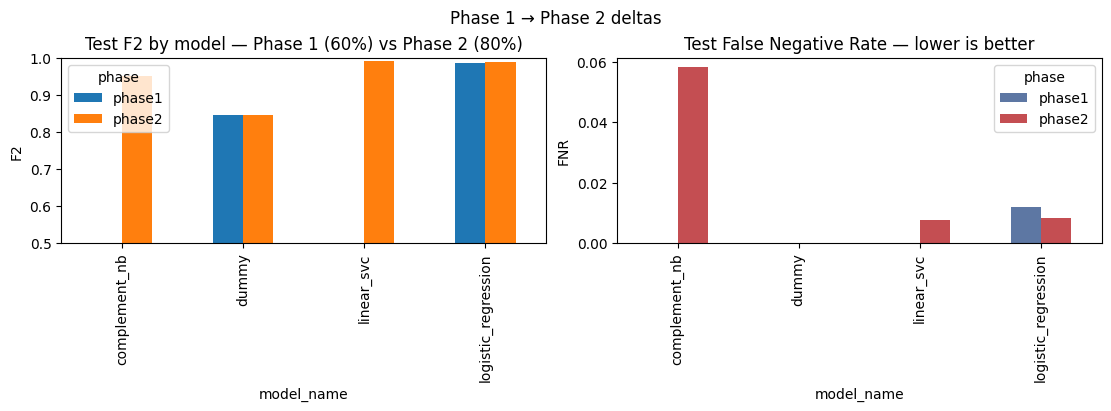

In [8]:
pivot = head_to_head.pivot(index="model_name", columns="phase", values="test_f2")
fpivot = head_to_head.pivot(index="model_name", columns="phase", values="test_false_negative_rate")

fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
pivot.plot.bar(ax=axes[0])
axes[0].set_title("Test F2 by model — Phase 1 (60%) vs Phase 2 (80%)")
axes[0].set_ylim(0.5, 1.0)
axes[0].set_ylabel("F2")

fpivot.plot.bar(ax=axes[1], color=["#5d77a3", "#c44e52"])
axes[1].set_title("Test False Negative Rate — lower is better")
axes[1].set_ylabel("FNR")
fig.suptitle("Phase 1 → Phase 2 deltas")
plt.show()

## 5. How does the Phase 1 baseline LR model behave on the new Phase 2 increment?

The Phase 1 baseline model isn't checked into Git (it lives in DVC/S3), so we approximate it by fitting an LR pipeline on the Phase 1 reference slice with the **same config**. We then score both the Phase 2 increment and the held-out Phase 2 test split with:

- the freshly-fit Phase 1-style model, and
- the saved Phase 2 best model.

This shows whether the extra 20 % of training data and the linear-SVC family help on the **new** rows specifically (i.e. the rows the Phase 1 model has never seen).

In [9]:
from mlops_crew.data.clean import clean_dataset
from mlops_crew.models.text_classifiers import build_text_classifier

phase1_cleaned, _ = clean_dataset(phase1_ref, config)
phase2_inc_cleaned, _ = clean_dataset(phase2_inc, config)

lr_pipeline = build_text_classifier("logistic_regression", config)
lr_pipeline.fit(phase1_cleaned[TEXT_COLUMN], phase1_cleaned[LABEL_COLUMN])

phase2_best = joblib.load(models_dir / "best_model.joblib")


def evaluate(model, df, label):
    preds = model.predict(df[TEXT_COLUMN])
    scores = None
    if hasattr(model, "predict_proba"):
        scores = model.predict_proba(df[TEXT_COLUMN])[:, 1]
    elif hasattr(model, "decision_function"):
        scores = model.decision_function(df[TEXT_COLUMN])
    report = binary_classification_report(df[LABEL_COLUMN], preds, scores)
    report["slice"] = label
    return report


rows = [
    {
        "model": "phase1_lr_on_phase2_increment",
        **evaluate(lr_pipeline, phase2_inc_cleaned, "phase2_increment"),
    },
    {
        "model": "phase2_best_on_phase2_increment",
        **evaluate(phase2_best, phase2_inc_cleaned, "phase2_increment"),
    },
]
cross_eval = pd.DataFrame(rows)[
    ["model", "slice", "f2", "recall", "false_negative_rate", "precision", "false_positive_rate"]
].round(4)
cross_eval

,model,slice,f2,recall,false_negative_rate,precision,false_positive_rate
0,phase1_lr_on_phase2_increment,phase2_increment,0.9900,0.9907,0.0093,0.9871,0.0141
1,phase2_best_on_phase2_increment,phase2_increment,0.9974,0.9977,0.0023,0.9965,0.0038


## 6. False-negative deep dive on the Phase 2 test split

Missed phishing emails matter more than false alarms. Pull the test-set predictions saved by the pipeline (`reports/predictions/<best>_test_predictions.csv`) and look at the misses.

In [10]:
pred_path = PROJECT_ROOT / best["test_prediction_path"]
test_preds = pd.read_csv(pred_path)
false_negatives = test_preds[(test_preds["label"] == 1) & (test_preds["prediction"] == 0)]
false_positives = test_preds[(test_preds["label"] == 0) & (test_preds["prediction"] == 1)]
print(f"Test rows: {len(test_preds):,}")
print(
    f"False negatives: {len(false_negatives)}  (FNR {len(false_negatives) / max(1, (test_preds['label'] == 1).sum()):.4%})"
)
print(
    f"False positives: {len(false_positives)}  (FPR {len(false_positives) / max(1, (test_preds['label'] == 0).sum()):.4%})"
)
false_negatives.head(5)[
    [TEXT_COLUMN, "label", "prediction"] + (["score"] if "score" in false_negatives.columns else [])
]

Test rows: 9,862
False negatives: 40  (FNR 0.7778%)
False positives: 67  (FPR 1.4198%)


,text_combined,label,prediction,score
306,cfp int conf web delivering music wedelmusic 2...,1,0,-1.574284
340,creativity innovation newsletter march 2005 vo...,1,0,-0.114105
425,elliott gideon qbinwheelscom cream crop 2007 g...,1,0,-1.081919
839,der neue kontaktanzeigen markt roter sueden se...,1,0,-0.023356
1463,intrigue geelkoperemmer cpzamatbignode kirstei...,1,0,-0.261128


## 7. MLflow runs produced by this Phase 2 training

The pipeline opens one parent MLflow run (`phase{N}-training`) per training invocation and one nested run per model. To browse them:

```bash
make mlflow-ui    # serves http://localhost:5001
```

We can also enumerate the locally-stored runs programmatically.

In [11]:
import mlflow

tracking_uri = config["tracking"]["tracking_uri"]
if tracking_uri.startswith("file:./"):
    tracking_uri = f"file:{PROJECT_ROOT / tracking_uri.removeprefix('file:./')}"
mlflow.set_tracking_uri(tracking_uri)

experiment = mlflow.get_experiment_by_name(config["tracking"]["experiment_name"])
if experiment is None:
    print("No experiment yet - run `make repro` first.")
else:
    runs = mlflow.search_runs(experiment_ids=[experiment.experiment_id], output_format="pandas")
    run_name_col = "tags.mlflow.runName"
    parent_col = "tags.mlflow.parentRunId"
    if parent_col not in runs.columns:
        runs[parent_col] = pd.NA

    parents = runs[
        (runs[run_name_col] == "phase2-training")
        & (runs[parent_col].isna())
        & (runs["status"] == "FINISHED")
    ].copy()

    print(f"Experiment: {experiment.name} (id={experiment.experiment_id})")
    if parents.empty:
        print("No completed parent training run yet - run `make repro` first.")
    else:
        latest_parent = parents.sort_values("start_time", ascending=False).iloc[0]
        child_runs = runs[runs[parent_col] == latest_parent["run_id"]].copy()
        keep = [
            c
            for c in [
                "tags.mlflow.runName",
                "status",
                "metrics.validation_f2",
                "metrics.test_f2",
                "metrics.test_recall",
                "metrics.test_false_negative_rate",
            ]
            if c in child_runs.columns
        ]
        print(f"Latest completed training run: {latest_parent['run_id']}")
        print(f"Child runs in latest invocation: {len(child_runs)}")
        child_runs[keep].sort_values("tags.mlflow.runName").reset_index(drop=True)

Experiment: phishing-email-phase2 (id=987205410973768974)
Latest completed training run: 5dac43c536c049bb9f18c1ebb4bb154b
Child runs in latest invocation: 4


/Users/krishnakalakonda/Downloads/ML Ops/mlops_crew/.venv/lib/python3.12/site-packages/mlflow/tracking/_tracking_service/utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)


## 8. Phase 2 model-development takeaways

- Phase 1 baseline (60 % data, LR only): test F2 ≈ 0.987, test FNR ≈ 0.0119.
- Phase 2 winner (80 % data, Linear SVC): test F2 ≈ 0.991, test FNR ≈ 0.0078.
- F2 lift is small (≈ +0.4 pp) because the Phase 1 model was already strong on this dataset; the bigger story is the **≈35 % reduction in false negatives**, which is exactly what we optimize for in phishing detection.
- The 20 % Phase 3 holdout is untouched and reserved for the next phase.
- Every number above is sourced from a committed file in `reports/metrics/` or recomputed live from `data/processed/` — nothing is hand-typed.

See `notebooks/phase2_divergence_analysis.ipynb` for the data-drift view of the same comparison.